In [1]:

import os
import cv2
import csv
import mediapipe as mp
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from collections import defaultdict, Counter, deque
from scipy.spatial.distance import cdist
from collections import Counter
import joblib



In [7]:
#extract keypoints from images and save to CSV

def extract_keypoints(dataset_path, csv_file):
    file_list = {}

    for cls in os.listdir(dataset_path):
        cls_path = os.path.join(dataset_path, cls)
        if os.path.isdir(cls_path):
            images = [os.path.join(cls_path, f) for f in os.listdir(cls_path)]
            file_list[cls] = images

    landmarks = ['class']
    for val in range(1, 22):
        landmarks += ['x{}'.format(val), 'y{}'.format(val)]  # Header CSV: class + 21 keypoints (x,y)

    with open(csv_file, mode='w', newline='') as f: 
        csv_writer = csv.writer(f, delimiter=',', quotechar='"', quoting=csv.QUOTE_MINIMAL)
        csv_writer.writerow(landmarks)

    mp_hands = mp.solutions.hands
    with mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.5) as hands: #if mediaPiepe is not too confident, skip the image

        for cls, files in file_list.items(): # iterate through each class and its files
            print(f"Processing class: {cls}") 

            for file in files:
                image = cv2.imread(file)
                if image is None:
                    continue
                image = cv2.flip(image, 1)
                results = hands.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)) #process image to find hand landmarks

                try:
                    for hand_landmark in results.multi_hand_landmarks: #if hand landmarks are found
                        keypoints = list(np.array([[lm.x, lm.y] for lm in hand_landmark.landmark]).flatten()) # extract x,y coordinates of each landmark
                        row = [cls] + keypoints
                        with open(csv_file, mode='a', newline='') as f:
                            csv_writer = csv.writer(f, delimiter=',', quotechar='"', quoting=csv.QUOTE_MINIMAL)
                            csv_writer.writerow(row)
                except:
                    pass

In [ ]:
train_path = "asl_alphabet_train"

#extract train keypoints and save to CSV

extract_keypoints(train_path, "hand_dataset_train.csv")


Processing class: A
Processing class: B
Processing class: C
Processing class: D
Processing class: E
Processing class: F
Processing class: G
Processing class: H
Processing class: I
Processing class: J
Processing class: K
Processing class: L
Processing class: M
Processing class: N
Processing class: O
Processing class: P
Processing class: Q
Processing class: R
Processing class: S
Processing class: T
Processing class: U
Processing class: V
Processing class: W
Processing class: X
Processing class: Y
Processing class: Z


In [ ]:
test_path = "asl_alphabet_test"

#extract test keypoints and save to CSV

extract_keypoints(test_path, "hand_dataset_test.csv")

Processing class: A
Processing class: B
Processing class: C
Processing class: D
Processing class: E
Processing class: F
Processing class: G
Processing class: H
Processing class: I
Processing class: J
Processing class: K
Processing class: L
Processing class: M
Processing class: N
Processing class: O
Processing class: P
Processing class: Q
Processing class: R
Processing class: S
Processing class: T
Processing class: U
Processing class: V
Processing class: W
Processing class: X
Processing class: Y
Processing class: Z


In [2]:
#Load train and test datasets with keypoint's coordinates

train_dataset = pd.read_csv("hand_dataset_train.csv")

X = train_dataset.iloc[:, 1:].values
Y = train_dataset.iloc[:, 0].values

# Split in train and validation sets

X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

test_dataset = pd.read_csv("hand_dataset_test.csv")

X_test = test_dataset.iloc[:, 1:].values
y_test = test_dataset.iloc[:, 0].values


In [3]:
#standardize keypoints coordinates

scaler = StandardScaler().fit(X_train)

X_train = scaler.transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("Observations and features train:", X_train.shape)
print("Observations and features validation:", X_val.shape)
print("Observations and features test:", X_test.shape)

Observations and features train: (21576, 42)
Observations and features validation: (5394, 42)
Observations and features test: (2952, 42)


In [4]:
#Validation set is used to find the best k

k_values = list(range(1, 21))  #try k from 1 to 20
best_k = 1
best_val_acc = 0

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)             # train with a specific k on the training set
    y_val_pred = knn.predict(X_val)       # prediction on the validation set
    val_acc = accuracy_score(y_val, y_val_pred)
    
    print(f"k={k}, Validation Accuracy={val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_k = k

print(f"\nBest k: {best_k} with validation accuracy={best_val_acc:.4f}")

k=1, Validation Accuracy=0.9359
k=2, Validation Accuracy=0.9164
k=3, Validation Accuracy=0.9166
k=4, Validation Accuracy=0.9067
k=5, Validation Accuracy=0.9030
k=6, Validation Accuracy=0.8978
k=7, Validation Accuracy=0.8893
k=8, Validation Accuracy=0.8891
k=9, Validation Accuracy=0.8860
k=10, Validation Accuracy=0.8817
k=11, Validation Accuracy=0.8804
k=12, Validation Accuracy=0.8758
k=13, Validation Accuracy=0.8754
k=14, Validation Accuracy=0.8684
k=15, Validation Accuracy=0.8648
k=16, Validation Accuracy=0.8634
k=17, Validation Accuracy=0.8591
k=18, Validation Accuracy=0.8576
k=19, Validation Accuracy=0.8552
k=20, Validation Accuracy=0.8519

Best k: 1 with validation accuracy=0.9359


In [5]:
#Re-train on training + validation set with the best k

X_train_full = np.vstack((X_train, X_val))
y_train_full = np.concatenate((y_train, y_val))

final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_full, y_train_full)

# Evaluate on the test set

y_test_pred = final_knn.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Test Accuracy con k={best_k}: {test_acc:.4f}")
print("\nClassification report (test set):")
print(classification_report(y_test, y_test_pred))

Test Accuracy con k=1: 0.6457

Classification report (test set):
              precision    recall  f1-score   support

           A       0.48      0.92      0.63       115
           B       0.99      1.00      1.00       115
           C       0.77      1.00      0.87       104
           D       0.91      0.25      0.39       115
           E       0.89      1.00      0.94       115
           F       1.00      1.00      1.00       115
           G       0.00      0.00      0.00       115
           H       0.63      1.00      0.77       115
           I       0.58      1.00      0.73       115
           J       1.00      0.31      0.48       115
           K       0.86      1.00      0.93       115
           L       0.77      0.98      0.86       115
           M       0.00      0.00      0.00       115
           N       0.98      0.40      0.57       114
           O       0.98      0.64      0.78        89
           P       0.29      0.80      0.43       115
           Q    

c:\Users\nicol\.venv11\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nicol\.venv11\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nicol\.venv11\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [6]:
# Save the scaler and the final model

joblib.dump(scaler, "scaler.pkl")
joblib.dump(final_knn, "knn_model.pkl")

['knn_model.pkl']

In [ ]:
# Conformal prediction adapted to k-NN classifier

# Split test into calibration and final test

X_calib, X_final, y_calib, y_final = train_test_split(X_test, y_test, test_size=0.8, stratify=y_test, random_state=42)

# Function for nonconformity score

labels = np.unique(y_train)
def nonconformity_score(x, y_label, X_train, y_train):
    mask_same_label = (y_train == y_label) 
    mask_other_label = (y_train != y_label) 

    dist_same = cdist([x], X_train[mask_same_label]) #distance to points with the same label
    dist_diff = cdist([x], X_train[mask_other_label]) #distance to points with different labels

    min_same = np.min(dist_same) if dist_same.size > 0 else np.inf 
    min_diff = np.min(dist_diff) if dist_diff.size > 0 else np.inf

    return min_same / min_diff if min_diff > 0 else np.inf # nonconformity score

# Compute non conformity scores for calibration set
calibration_scores = [nonconformity_score(x, y, X_train, y_train) for x, y in zip(X_calib, y_calib)]
calibration_scores = np.array(calibration_scores)

# Compute q_hat based on alpha
alpha = 0.3
q_hat = np.quantile(calibration_scores, 1 - alpha, interpolation='higher')

# Compute prediction sets for test set
prediction_sets = []
for x in X_final:
    preds = [label for label in labels if nonconformity_score(x, label, X_calib, y_calib) <= q_hat] #x is added if its nonconformity score is less than or equal to q_hat
    prediction_sets.append(preds)

# Show prediction sets for examples with cardinality > 1
for i, (x, preds, y_true) in enumerate(zip(X_final[:-1], prediction_sets[:-1], y_final[:-1])):
    if len(preds) > 1:
        covered = y_true in preds
        print(f"Test sample {i} - True label: {y_true} - Prediction set: {preds} - Covered: {covered}")

# Compute overall coverage
coverages = [y_true in preds for y_true, preds in zip(y_final, prediction_sets)]
coverage = np.mean(coverages)
print(f"Overall coverage: {coverage:.3f}")

# Average cardinality
avg_cardinality = np.mean([len(p) for p in prediction_sets])
print("Average cardinality of prediction sets:", avg_cardinality)


Test sample 26 - True label: R - Prediction set: ['R', 'U'] - Covered: True
Test sample 45 - True label: Y - Prediction set: ['A', 'Y'] - Covered: True
Test sample 59 - True label: M - Prediction set: ['A', 'E', 'M', 'N', 'S', 'T'] - Covered: True
Test sample 66 - True label: S - Prediction set: ['E', 'M', 'N', 'S', 'T'] - Covered: True
Test sample 80 - True label: E - Prediction set: ['E', 'S'] - Covered: True
Test sample 98 - True label: P - Prediction set: ['A', 'D', 'E', 'G', 'H', 'N', 'P', 'Q', 'S', 'T', 'X', 'Z'] - Covered: True
Test sample 107 - True label: Y - Prediction set: ['I', 'J', 'Y'] - Covered: True
Test sample 113 - True label: M - Prediction set: ['E', 'M', 'S'] - Covered: True
Test sample 117 - True label: A - Prediction set: ['A', 'M', 'T'] - Covered: True
Test sample 118 - True label: G - Prediction set: ['G', 'Q'] - Covered: True
Test sample 124 - True label: U - Prediction set: ['K', 'R', 'U', 'V'] - Covered: True
Test sample 128 - True label: Y - Prediction set:

Example index: 539, true label: T, prediction set: ['A', 'N', 'T']
Quantile q_hat=1.116 corrisponds to the position 413


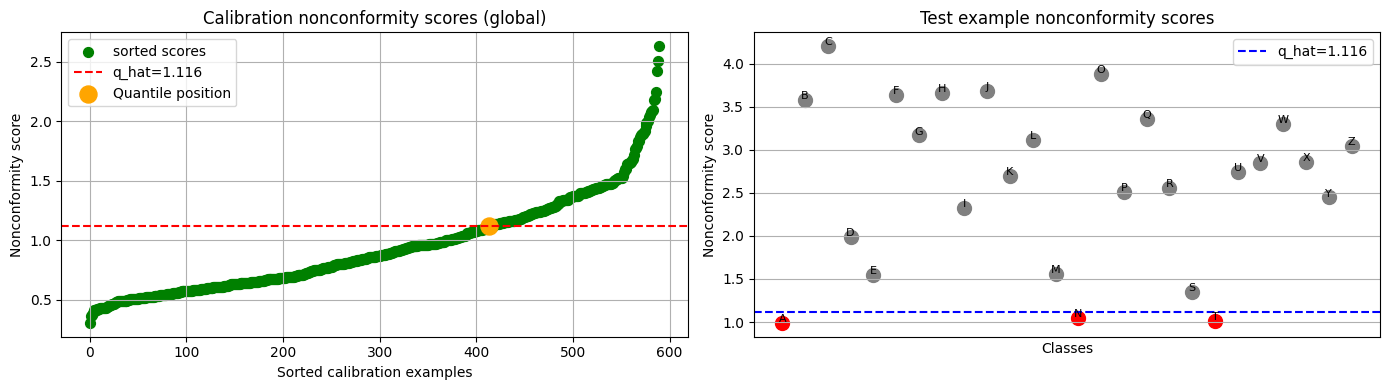

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


example_idx = None
for i, preds in enumerate(prediction_sets):
    if len(preds) == 3:
        example_idx = i
        break

x_example = X_final[example_idx]
y_example = y_final[example_idx]
print(f"Example index: {example_idx}, true label: {y_example}, prediction set: {prediction_sets[example_idx]}")


scores_calib_global = calibration_scores  
scores_sorted = np.sort(scores_calib_global)


q_hat_global = np.quantile(scores_sorted, 1 - alpha, interpolation='higher')


position = np.argmax(scores_sorted >= q_hat_global)
print(f"Quantile q_hat={q_hat_global:.3f} corrisponds to the position {position}")

plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
plt.title(f"Calibration nonconformity scores (global)")
plt.scatter(range(len(scores_sorted)), scores_sorted, color='green', s=50, label="sorted scores")
plt.axhline(q_hat_global, color='red', linestyle='--', label=f"q_hat={q_hat_global:.3f}")
plt.scatter(position, scores_sorted[position], color='orange', s=150, label="Quantile position")
plt.xlabel("Sorted calibration examples")
plt.ylabel("Nonconformity score")
plt.legend()
plt.grid(True)

scores_test = [nonconformity_score(x_example, label, X_calib, y_calib) for label in labels]
prediction_set_flags = np.array(scores_test) <= q_hat_global

plt.subplot(1,2,2)
plt.title(f"Test example nonconformity scores")
colors = ['red' if flag else 'gray' for flag in prediction_set_flags]
for i, label in enumerate(labels):
    plt.scatter(i, scores_test[i], color=colors[i], s=100)
    plt.text(i, scores_test[i]+0.01, label, ha='center', fontsize=8)
plt.axhline(q_hat_global, color='blue', linestyle='--', label=f"q_hat={q_hat_global:.3f}")
plt.ylabel("Nonconformity score")
plt.xlabel("Classes")
plt.xticks([])
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Real-time Sign Language Recognition


In [6]:
# Initialize mediapipe hand

mp_drawing = mp.solutions.drawing_utils
mp_hands = mp.solutions.hands

In [9]:
# Buffer for visual stability

prediction_buffer = deque(maxlen=10) 
stable_prediction_set = []

def get_stable_prediction_set(current_prediction_set):

    global prediction_buffer, stable_prediction_set
    
    prediction_buffer.append(current_prediction_set)
    
    # Not stable case (buffer not full)
    if len(prediction_buffer) < 5:
        return current_prediction_set
    
    class_counts = {}
    for pred_set in prediction_buffer:
        for class_label in pred_set:
            class_counts[class_label] = class_counts.get(class_label, 0) + 1
    
    # Only if the prediction appears in at least 60% of the buffer
    threshold = len(prediction_buffer) * 0.6
    stable_classes = [cls for cls, count in class_counts.items() if count >= threshold]
    
    # If no class is stable enough, use the most frequent prediction
    if not stable_classes:

        pred_tuples = [tuple(sorted(pred_set)) for pred_set in prediction_buffer]
        most_common = Counter(pred_tuples).most_common(1)[0][0]
        stable_classes = list(most_common)
    
    return stable_classes

# Mediapipe stuff #
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

# Initialize webcam
cap = cv2.VideoCapture(0)
with mp_hands.Hands(
    max_num_hands=1,
    min_detection_confidence=0.7,  
    min_tracking_confidence=0.7) as hands:  
    while cap.isOpened():
        success, image = cap.read()

        if not success:
            print("Ignoring empty camera frame.")
            continue

        # Flip the image horizontally for a later selfie-view display, and convert
        # the BGR image to RGB.
        image = cv2.cvtColor(cv2.flip(image, 1), cv2.COLOR_BGR2RGB)

        # To improve performance, optionally mark the image as not writeable to
        # pass by reference.
        image.flags.writeable = False
        results = hands.process(image)

        # Draw the hand annotations on the image.
        image.flags.writeable = True
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                coords = hand_landmarks.landmark
                mp_drawing.draw_landmarks(image, hand_landmarks, mp_hands.HAND_CONNECTIONS)
                coords = list(np.array([[landmark.x, landmark.y] for landmark in coords]).flatten())
                coords = scaler.transform([coords])
                
                # Current prediction set
                current_prediction_set = [label for label in labels if nonconformity_score(coords[0], label, X_calib, y_calib) <= q_hat]
                
                # Stable prediction for buffer
                stable_prediction_set = get_stable_prediction_set(current_prediction_set)

            # Dynamic box height for visualization
            box_height = 40 + len(stable_prediction_set) * 25  
            cv2.rectangle(image, (0, 0), (200, box_height), (245, 90, 16), -1)

            # Show the stable prediction set and its cardinality
            cv2.putText(image, 'PREDICTION SET:', (10, 15), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)
            
            for i, pred_class in enumerate(stable_prediction_set):
                cv2.putText(image, f'Class {pred_class}', (10, 35 + i * 25), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)
            
            cv2.putText(image, f'Cardinality: {len(stable_prediction_set)}', (10, 35 + len(stable_prediction_set) * 25), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 200, 200), 1, cv2.LINE_AA)
        else:
            # Resetting the buffer
            prediction_buffer.clear()
            stable_prediction_set = []

        cv2.imshow('MediaPipe Hands - Conformal Prediction', image)

        # Press esc to close webcam
        if cv2.waitKey(5) & 0xFF == 27:
            break

cap.release()
cv2.destroyAllWindows()